## Imports and utilitaries

Run all cells in this section before simulating.


In [1]:
# copied from all_possible_paths.py
 
### In this script I can try all the different combinations of actions for the AV agents.
import itertools
import os
import pandas as pd
import numpy as np
import latex
import scienceplots
import csv
import torch
from tensordict.nn import TensorDictModule, TensorDictSequential
from torchrl.envs.libs.pettingzoo import PettingZooWrapper
from torchrl.envs.transforms import TransformedEnv, RewardSum
from torchrl.envs.utils import check_env_specs
from torch import nn
from torchrl._utils import logger as torchrl_logger
from torchrl.collectors import SyncDataCollector
from torchrl.data import TensorDictReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage
from torchrl.modules import EGreedyModule, QValueModule, SafeSequential
from torchrl.modules.models.multiagent import MultiAgentMLP
from torchrl.objectives import SoftUpdate, ValueEstimators, DQNLoss

from routerl import TrafficEnvironment

from routerl.keychain import Keychain as kc
from routerl.utilities import get_params

os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

import matplotlib.lines as lines
import matplotlib.patches as patches
from matplotlib.patches import ConnectionPatch

viridis = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=5, vmax=10)

C:\Users\Utilisateur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchrl\data\replay_buffers\samplers.py:37: UserWarning: Failed to import torchrl C++ binaries. Some modules (eg, prioritized replay buffers) may not work with your installation. This is likely due to a discrepancy between your package version and the PyTorch version. Make sure both are compatible. Usually, torchrl majors follow the pytorch majors within a few days around the release. For instance, TorchRL 0.5 requires PyTorch 2.4.0, and TorchRL 0.6 requires PyTorch 2.5.0.
  warnings.warn(EXTENSION_WARNING)


### `run(tl_0, tl_1, tl_y, nbagents)` :
* generates a two-route-trafficlight network with the specified traffic light times (writes a .net.xml file **both** within the RouteRL module (for execution), and within the ..\networks\two_route_trafficlight folder (for safekeeping). Make sure both paths exist on the machine otherwise it won't run.);
* initializes the SUMO environment with the specified number of agents, then mutates 10 of them into AVs (the selection uses the default seed defined within the RouteRL framework);
* runs the simulation for all 1024 possible AV joint actions;
* writes the payoff matrix inside the `reward_df_(tl_0)_(tl_1)_(tl_y)_(nbagents)agents.csv` file.

In [2]:
def run(tl_0, tl_1, tl_y, nbagents,open_gui=False):

    '''
    - generates a two-route-trafficlight network with the specified traffic light times (writes a .net.xml file **both** within the RouteRL module (for execution), and within the ../networks/two_route_trafficlight folder (for safekeeping). Make sure both paths exist on the machine otherwise it won't run.);
    - initializes the SUMO environment with the specified number of agents;
    - runs the simulation for all 1024 possible AV joint actions;
    - writes the payoff matrix inside the `reward_df_(tl_0)_(tl_1)_(tl_y)_(nbagents)agents.csv` file.

    Set open_gui to True to open the simulation GUI.
    '''

    filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1, tl_y, nbagents)
    update_trafficlight(tl_0, tl_1, tl_y)
    simulate(nbagents,open_gui)
    record_experiment(filename)


In [3]:
def update_trafficlight(t0,t1,ty,offset=0):

    '''
    t0 = time of green light for route 0, red light for route 1 \\
    t1 = time of red light for route 0, green light for route 1 \\
    ty = time of yellow light for both routes (symmetrical)

    This function updates the network file used for simulations. \\
    !!! Verify paths exist on your machine !!!
    '''

    # template file
    read_file_name = "../networks/two_route_trafficlight/two_route_trafficlight.net.xml"

    # path within the RouteRL module
    write_file_name = "C:/Users/Utilisateur/AppData/Local/Packages/PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0/LocalCache/local-packages/Python313/site-packages/routerl/networks/two_route_trafficlight/two_route_trafficlight.net.xml"

    # path within the /networks/ folder
    network_file_name = "../networks/two_route_trafficlight/two_route_trafficlight.net.xml"

    tllogic = []
    tllogic.append( "\t<tlLogic id=\"J2\" type=\"static\" programID=\"0\" offset=\"%s\">\n"%(offset))
    tllogic.append( "\t\t<phase duration=\"%s\" state=\"Gr\"/>\n"%(t1))
    tllogic.append( "\t\t<phase duration=\"%s\"  state=\"yr\"/>\n"%(ty))
    tllogic.append( "\t\t<phase duration=\"%s\" state=\"rG\"/>\n"%(t0))
    tllogic.append( "\t\t<phase duration=\"%s\"  state=\"ry\"/>\n"%(ty))
    tllogic.append( "\t</tlLogic>\n")

    with open(read_file_name, "r") as fr:
        lines = fr.readlines()
        print(lines)

    with open(write_file_name, "w") as fw:
        fw.writelines(lines[:76])
        fw.writelines(tllogic)
        fw.writelines(lines[82:])

    with open(network_file_name, "w") as fw:
        fw.writelines(lines[:76])
        fw.writelines(tllogic)
        fw.writelines(lines[82:])
    
    return None

In [4]:
def create_environment(nb_agents=23,open_gui=False):
    sumo_type = "sumo-gui" if open_gui else "sumo" # opening the GUI might be useful for debugging.
    env = TrafficEnvironment(
        agent_parameters={
            "num_agents": nb_agents, 
            "new_machines_after_mutation": 10, 
            "machine_parameters": {
                "behavior": "selfish"
                }
            },
        simulator_parameters={
            "network_name": "two_route_trafficlight",
            "sumo_type": sumo_type,
            "custom_network_folder": "../networks/two_route_trafficlight",
            },
        path_generation_parameters={
            "origins": ["E0"],
            "destinations": ["E2"],
            "number_of_paths": 2
            }
        )
    return env


In [5]:
def simulate(nb_agents=23,open_gui=False):

    env = create_environment(nb_agents,open_gui)
    env.start()
    env.mutation()

    actions = [0, 1]
    print("env.human_agents", env.human_agents)
    print("env.machine_agents", env.machine_agents)
    print("\n")

    env.reset()

    i = 0
    k = 1
    for combination in itertools.product(actions, repeat=len(env.possible_agents)):
        i += 1
        for action in combination:
            env.step(action)
        if i > k*1024/10:
            print("%s combinations out of 1024 tested, %s%s remaining"%(i,(10-k)*10,"%"))
            k += 1

        env.reset()
    
    env.stop_simulation()


In [6]:
def build_df(i):

    '''
    Returns the payoff matrix from the last experiment as a pandas DataFrame.
    '''
    
    df = pd.read_csv("training_records/episodes/ep"+str(i)+".csv")
    df = df[df["kind"] == "AV"]
    df = df.sort_values(by="start_time").reset_index(drop=True)
    df["reward"] = -1*df["travel_time"]
    df = df[["reward","action"]]
    return df


In [7]:
def write_line(i,df):
    '''
    Auxiliary function for `record_experiment()`
    '''
    line = str(i)
    for i in range(10):
        line = line + "," + str(df["reward"].values[i])
    return line


In [8]:
def record_experiment(file_name):

    '''
    Writes down the payoff matrix from the last experiment into the file (file name entered as input)
    '''

    with open(file_name, "w") as f:
        f.write("id,0,1,2,3,4,5,6,7,8,9\n")
        for i in range(1024):
            data = build_df(i+1)
            text = write_line(i,data)
            f.write(text+"\n")

In [9]:
def run_exp(tl_0, tl_1, tl_y, nbagents,nbsamples=1,open_gui=False):

    '''
    Calculates expected values of the payoff matrix for the specified two-route-trafficlight network, over 'nbsamples' runs made with offset values uniformly distributed over the total cycle length.
    '''
    cyclelength = tl_0 + tl_1 + 2*tl_y
    les_offsets = [i*cyclelength/nbsamples for i in range(nbsamples)]
    tab = np.zeros((10,1024))
    
    for i in range(nbsamples):
        offset = les_offsets[i]
        filename = "reward_df_%s_%s_%s_%sagents_%soffset.csv"%(tl_0,tl_1, tl_y, nbagents,offset)
        try:
            tab_reward = pd.read_csv(filename)
        except:
            print("Reward table for tl_0 = %s, tl_1 = %s, tl_y = %s and %s agents, with offset = %s, was not found. Running..."%(tl_0,tl_1,tl_y,nbagents,offset))
            update_trafficlight(tl_0, tl_1, tl_y, offset)
            simulate(nbagents,open_gui)
            record_experiment(filename)
            tab_reward = pd.read_csv("reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1,tl_y,nbagents))
        for i in range(10):
            tab[i] += tab_reward[i]
    
    tab = tab/nbsamples
    filename = "reward_df_%s_%s_%s_%sagents_%ssamples.csv"%(tl_0,tl_1, tl_y, nbagents,nbsamples)
    with open(filename, "w") as f:
        f.write("id,0,1,2,3,4,5,6,7,8,9\n")
        for row in range(1024):
            line = str(row)
            for i in range(10):
                line = line + "," + str(tab[i][row])
            f.write(line+"\n")
    

In [10]:
def simulate_action(strategy,nb_agents=23,open_gui=True):

    action = (x for x in strategy)

    env = create_environment(nb_agents,open_gui)
    env.start()
    env.mutation()

    print("env.human_agents", env.human_agents)
    print("env.machine_agents", env.machine_agents)
    print("\n")

    env.reset()
    env.step(action)
    
    env.stop_simulation()

In [11]:
def simulate_coalition(coalition,nb_agents=23):

    action = coalition_to_strategy(coalition)
    simulate_action(action,nb_agents)

### Data structures and objects

`id` is a number between 0 and 1023, referencing one of the 1024 possible joint actions of the players and the id'th line of a payoff matrix.

`strategy` is an array of size 10, where `strategy[i]` indicates the route choice of player `i`.

`coalition` is an array, containing a subset of [0..9].

In [12]:
def id_to_strategy(id):
    '''
    INPUT :`id`= integer from`[0,1023]`

    OUTPUT :`strategy`= array of size 10, binary representation of number`id`
    '''
    strategy = [0 for _ in range(10)]
    i = 0
    while id > 0:
        if id % 2 == 1:
            strategy[9-i] = 1
        id = id//2
        i += 1
    return strategy


In [13]:
def strategy_to_id(s):
    '''
    INPUT :`strategy`= array of size 10, binary representation of number`id`

    OUTPUT :`id`= integer within`[0,1023]`
    '''
    id = 0
    for i in range(10):
        id += s[i]*(2**(9-i))
    return id


In [14]:
def coalition_to_strategy(coalition):
    '''
    INPUT :`coalition`= subset of [0,9]

    OUTPUT :`strategy`= array of size 10,`strategy[i] = 1`iff i is in the coalition

    NOTE :`strategy_to_coalition(id_to_strategy())`may be used to map an integer to a subset of [0,9]
    '''
    s = [0 for _ in range(10)]
    for i in coalition:
        s[i] = 1
    return s


In [15]:
def strategy_to_coalition(s):
    '''
    INPUT :`strategy`= array of size 10
    
    OUTPUT :`coalition`= subset of [0,9],`strategy[i] = 1`iff i is in the coalition

    NOTE :`strategy_to_coalition(id_to_strategy())`may be used to map an integer to a subset of [0,9]
    '''
    coalition = []
    for i in range(10):
        if s[i] == 1:
            coalition.append(i)
    return coalition


In [16]:
def neighbouring_strategies(s):

    '''
    INPUT :`s`= array of size n, describing the joint actions of the 10 AVs (route 0 or 1) \\
    OUTPUT : array of all 10 joint actions, each one with one of the AVs deviating from`s`
    '''

    neigh = [ [s[j] for j in range(10)] for _ in range(10)]
    for i in range(10):
        neigh[i][i] = 1 - neigh[i][i]
    return neigh


In [17]:
def neighbouring_ids(id):
    
    '''
    goes from the space of ids (integers in`0..1023`) to strategies, then to neighbouring strategies (see`neighbouring_strategies()`), and back to ids.
    '''

    s = id_to_strategy(id)
    t = neighbouring_strategies(s)
    neigh = []
    for i in range(10):
        neigh.append(strategy_to_id(t[i]))
    return neigh


### Building reward tables

Functions to build a 10x1024 payoff matrix from a given experiment record or from custom dynamic traffic light parameters, and access it through the objects.

In [18]:
def build_rewardtable(file_name):

    '''
    Returns the payoff matrix from an experiment (stored in the file given as input) as an array.

    !! Will crash if the file does not exist.
    '''

    df_reward = pd.read_csv(file_name)
    tab = np.zeros((10,1024))
    for i in range(10):
        tab[i] = df_reward[str(i)].values
    return tab


In [19]:
def custom_df(tl_list, custom_filename = "reward_df_custom.csv"):

    '''
    `tl_list`is an array of size 11. For each i in [0...10],`tl_list[i]`is a tuple`(tl_0,tl_1,tl_y,nb_agents)`, representing specific parameters of a network with static traffic lights.

    `custom_df`builds the payoff matrix of a network with dynamic traffic lights, where whenever n AVs choose route 1, traffic lights are set to`tl_list[n]`
    '''

    assert len(tl_list) == 11

    f = open(custom_filename,"w")
    
    f.write("id,0,1,2,3,4,5,6,7,8,9\n")
    for id in range(1024):

        s = id_to_strategy(id)
        n_1 = 0
        for j in range(10):
            n_1 += s[j]
        tl_0,tl_1,tl_y,nb_agents = tl_list[n_1]

        try:
            df_reward = pd.read_csv("reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1,tl_y,nb_agents))
        except:
            print("Reward table for tl_0 = %s, tl_1 = %s, tl_y = %s and %s agents was not found. Running..."%(tl_0,tl_1,tl_y,nb_agents))
            run(tl_0,tl_1,tl_y,nb_agents)
            df_reward = pd.read_csv("reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1,tl_y,nb_agents))

        text = str(id)
        tab_reward = [[] for _ in range(10)]
        for i in range(10):
            tab_reward[i] = df_reward[str(i)].values
            text = text + "," + str(float(tab_reward[i][id]))

        f.write(text+"\n")

In [20]:
def reward(i,id):
    return float(tab_reward[i][id])


In [21]:
def id_to_reward(id):
    return [reward(i,id) for i in range(10)]


In [22]:
def s_to_reward(s):
    id = strategy_to_id(s)
    return id_to_reward(id)


### Algorithms for Nash and strong equilibria

In [23]:
def nash_deviation(s):
    
    '''
    for a given strategy/joint action`s`, returns an array of size 10`dev`.

    For i in 0..9,`dev[i]`is what the AV number i can gain by deviating ALONE from`s`.
    '''

    rew = s_to_reward(s)
    neigh = neighbouring_strategies(s)
    dev = []
    for i in range(10):
        alternative = s_to_reward(neigh[i])[i]
        dev.append(alternative - rew[i])
    return dev


In [24]:
def nash_equilibrium(s):
    
    '''
    runs`nash_deviation(s)`, verifies if any AV can gain by deviating from`s`, and answers whether`s`is a Nash equilibrium.
    '''

    dev = nash_deviation(s)
    for i in range(10):
        if dev[i] > 0:
            return False
    return True


In [25]:
def strong_nash_equilibrium(s,verbose=True):
    
    '''
    verifies that no subset (aka coalition) of the set of AVs can deviate from`s`. \\
    A coalition deviates if every member increases its payoff when the whole coalition deviates.\\
    Add `verbose=False` if you do not want to print coalitions eligible for a deviation.
    '''

    rew = s_to_reward(s)
    list_c = []
    for id in range(1,1024):
        coalition = strategy_to_coalition(id_to_strategy(id))
        neigh_s = [s[i] for i in range(10)]
        for i in coalition:
            neigh_s[i] = 1 - s[i]
        alt = s_to_reward(neigh_s)
        coalition_deviates = True
        for i in coalition:
            if alt[i] - rew[i] <= 0:
                coalition_deviates = False
        if coalition_deviates:
            list_c.append(coalition)
    if verbose:
        for c in list_c:
            print(c)
    return len(list_c) == 0


In [26]:
def individual_deviations(s):
    
    '''
    runs`nash_deviation(s)`, and returns the list of AVs that can gain by deviating from`s`.
    '''

    dev = nash_deviation(s)
    list_i = []
    for i in range(10):
        # we do not verify if the first AV can deviate. Otherwise, no non-trivial NE will be found.
        if dev[i] > 0:
            list_i.append(i)
    return list_i

In [27]:
def coalition_deviations(s):
    
    '''
    Returns coalitions that may deviate from `s`.
    '''

    rew = s_to_reward(s)
    list_c = []
    for id in range(1,1024):
        coalition = strategy_to_coalition(id_to_strategy(id))
        neigh_s = [s[i] for i in range(10)]
        for i in coalition:
            neigh_s[i] = 1 - s[i]
        alt = s_to_reward(neigh_s)
        coalition_deviates = True
        for i in coalition:
            if alt[i] - rew[i] <= 0:
                coalition_deviates = False
        if coalition_deviates:
            list_c.append(coalition)
    return list_c

## Finding a club

Not all instances of TWO-ROUTE allow a club to form. A club forms if the initial situation $x^0$ (where all AV agents drive on route 0) is a Nash equilibrium (no agent deviates individually) but not a strong equilibrium (there exists a coalition that may form).

### Static traffic light systems

In static traffic light systems, the traffic light phases have a fixed duration whatever the flows are on each route. Clubs cannot form in such conditions (but you can try and have a look by yourself).

In [ ]:
# Verifying under which sets of static traffic light parameters
# having all AVs on route 0 is a (eventually strong) Nash equilibrium
#
# If a set of parameters has not been simulated yet, we run the simulation now.
# !!!! It takes quite some time! Check the next cell if you only want to use already-simulated instances.

snash_x, snash_y = [], []
nash_x, nash_y = [], []
notnash_x, notnash_y = [], []

nb_agents = 15      # number of human + AV agents in the network
tl_y = 5            # length of each yellow light phase

for tl_0 in range(10,42,2):
    for tl_1 in range(10,52-tl_0,2):
        filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1, tl_y, nb_agents)
        
        try:
            tab_reward = build_rewardtable(filename)
        except:
            print(tl_0,tl_1,tl_y, nb_agents)
            run(tl_0,tl_1,tl_y,nb_agents)
            tab_reward = build_rewardtable(filename)

        if nash_equilibrium(id_to_strategy(0)):
            if strong_nash_equilibrium(id_to_strategy(0)):
                snash_x.append(tl_0)
                snash_y.append(tl_1)
            else:
                nash_x.append(tl_0)
                nash_y.append(tl_1)
        else:
            notnash_x.append(tl_0)
            notnash_y.append(tl_1)

plt.scatter(snash_x, snash_y, color="g", label="Nash and strong equilibria")
plt.scatter(nash_x, nash_y, color="y", label="Nash but not strong equilibria")
plt.scatter(notnash_x, notnash_y, color="r", label="not Nash equilibria")
plt.xlabel("Green light duration on route 0")
plt.ylabel("Green light duration on route 1")
plt.legend()
plt.title("Is all-AVs-on-route-0 a (strong) Nash equilibrium? Nbagents = %s"%(nb_agents))
plt.show()


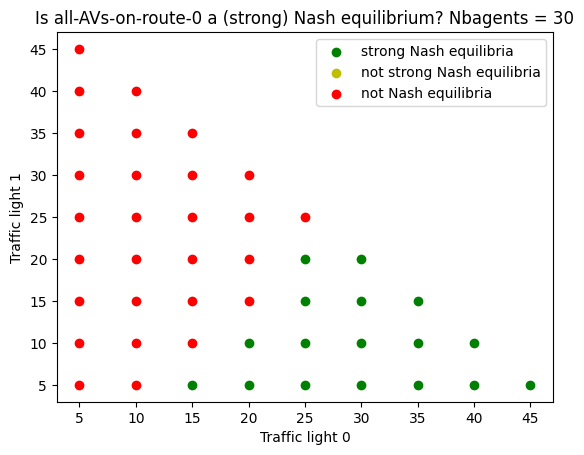

In [ ]:
# Verifying, **among all sets of parameters already run**, under which sets of static traffic light parameters
# having all AVs on route 0 is a Nash equilibrium, and eventually a strong Nash equilibrium.

snash_x, snash_y = [], []
nash_x, nash_y = [], []
notnash_x, notnash_y = [], []

nb_agents = 30      # number of human + AV agents in the network
tl_y = 5            # length of each yellow light phase

for tl_0 in range(5,50,5):
    for tl_1 in range(5,50,5):
        filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0, tl_1, tl_y, nb_agents)
        
        try:
            tab_reward = build_rewardtable(filename)
        except:
            # Running a simulation takes way more time than using reward tables that have already been calculated.
            x=0
        
        if nash_equilibrium(id_to_strategy(0)):
            if strong_nash_equilibrium(id_to_strategy(0)):
                snash_x.append(tl_0)
                snash_y.append(tl_1)
            else:
                nash_x.append(tl_0)
                nash_y.append(tl_1)
        else:
            notnash_x.append(tl_0)
            notnash_y.append(tl_1)

plt.scatter(snash_x, snash_y, color="g", label="Nash and strong equilibria")
plt.scatter(nash_x, nash_y, color="y", label="Nash but not strong equilibria")
plt.scatter(notnash_x, notnash_y, color="r", label="not Nash equilibria")
plt.xlabel("Green light duration on route 0")
plt.ylabel("Green light duration on route 1")
plt.legend()
plt.title("Is all-AVs-on-route-0 a (strong) Nash equilibrium? Nbagents = %s"%(nb_agents))
plt.show()

### Dynamic traffic light systems

In dynamic traffic light systems, the structure of the traffic light cycle depends on the flow on route 1. Such a system is defined by a function that assigns parameters of a static traffic light system to each possible value of vehicle flows $$ \varphi(q_0,q_1) \mapsto (tl_0,tl_1,tl_y) $$
To calculate the payoff matrix $g$ of such a system, we select rows from payoff matrices in static traffic light systems, such that for each joint action $x$ with vehicle flows $q_0,q_1$, the rows associated to $x$ are the same in $g$ and in $g^{\varphi(q_0,q_1)}$.

In the paper, we consider only dynamic TL systems with two states where the green light on route 1 becomes longer after the flow $q_1$ reaches a certain threshold $t \in [0 \dots N]$. But the function `custom_df` allows for more complex definitions of $\varphi$.

(15,25) below threshold, (1,39) above threshold
(15,25) below threshold, (2,38) above threshold
(15,25) below threshold, (3,37) above threshold
(15,25) below threshold, (4,36) above threshold
(15,25) below threshold, (5,35) above threshold
(15,25) below threshold, (6,34) above threshold
(15,25) below threshold, (7,33) above threshold
(15,25) below threshold, (8,32) above threshold
(15,25) below threshold, (9,31) above threshold
(15,25) below threshold, (10,30) above threshold
(15,25) below threshold, (11,29) above threshold
(15,25) below threshold, (12,28) above threshold
(15,25) below threshold, (13,27) above threshold
(15,25) below threshold, (14,26) above threshold
(16,24) below threshold, (1,39) above threshold
(16,24) below threshold, (2,38) above threshold
(16,24) below threshold, (3,37) above threshold
(16,24) below threshold, (4,36) above threshold
(16,24) below threshold, (5,35) above threshold
(16,24) below threshold, (6,34) above threshold
(16,24) below threshold, (7,33) abo

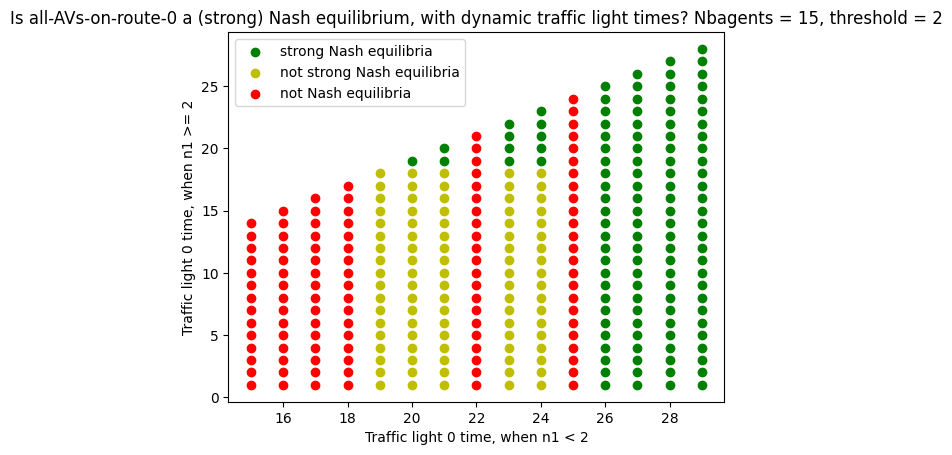

In [ ]:
# Checking under which parameters of a dynamic-traffic-light network, having all AVs on route 0 is a (strong) Nash equilibrium.
# Said parameters are the traffic light durations with few AVs on route 1, and durations with more AVs on route 1.
# 'threshold' is the number of AVs on route 1 necessary to switch between these two modes.

snash_x, snash_y = [], []
nash_x, nash_y = [], []
notnash_x, notnash_y = [], []

nb_agents = 15      # number of human + AV agents in the network
threshold = 2       # number of AVs on route 1 beyond which the traffic lights adapt
tl_y = 5            # length of each yellow light phase
cycle_length = 50   # total length of the traffic light cycle

for tl_0_below_threshold in range(15,30):
    for tl_0_above_threshold in range(1,tl_0_below_threshold):

        # build traffic light system and payoff matrix
        tl_1_below_threshold = cycle_length - 2*tl_y - tl_0_below_threshold
        tl_1_above_threshold = cycle_length - 2*tl_y - tl_0_above_threshold
        print("Green light durations on each route are (%s,%s) below threshold, (%s,%s) above threshold"%(tl_0_below_threshold,tl_1_below_threshold,tl_0_above_threshold,tl_1_above_threshold))
        tl_list = [(tl_0_below_threshold,tl_1_below_threshold,tl_y,nb_agents) if nb_1 < threshold else (tl_0_above_threshold,tl_1_above_threshold,tl_y,nb_agents) for nb_1 in range(11)]
        custom_df(tl_list)
        tab_reward = build_rewardtable("reward_df_custom.csv")

        # check equilibrium status
        if nash_equilibrium(id_to_strategy(0)):
            if strong_nash_equilibrium(id_to_strategy(0)):
                snash_x.append(tl_0_below_threshold)
                snash_y.append(tl_0_above_threshold)
            else:
                nash_x.append(tl_0_below_threshold)
                nash_y.append(tl_0_above_threshold)
        else:
            notnash_x.append(tl_0_below_threshold)
            notnash_y.append(tl_0_above_threshold)

plt.scatter(snash_x, snash_y, color="g", label="Nash and strong equilibria")
plt.scatter(nash_x, nash_y, color="y", label="Nash but not strong equilibria")
plt.scatter(notnash_x, notnash_y, color="r", label="not Nash equilibria")
plt.xlabel("Green light duration on route 0, when n1 < %s"%(threshold))
plt.ylabel("Green light duration on route 0, when n1 >= %s"%(threshold))
plt.legend()
plt.title("Is all-AVs-on-route-0 a (strong) Nash equilibrium, with dynamic traffic light times? Nbagents = %s, threshold = %s"%(nb_agents,threshold))
plt.show()

## Testing scripts, sample code

### Test runs on static traffic light systems

In [ ]:
# Test runs here (static traffic light systems)

# Set parameters
nb_agents = 23  # number of human + AV agents in the network
tl_0 = 33       # length of the "green on route 0, red on route 1" phase
tl_1 = 17       # length of the "red on route 0, green on route 1" phase
tl_y = 5        # length of each yellow light phase

cycle_length = tl_0 + tl_1 + 2*tl_y
print("Test run: lights are green for %s seconds on route 0 and %s seconds on route 1.\nTotal traffic light cycle is %s seconds long.\nThere are %s agents."%(tl_0,tl_1,cycle_length,nb_agents))
run(tl_0,tl_1,tl_y,nb_agents)

In [ ]:
# EXPERIMENTAL: Computing payoff matrices with expected values (the offset of traffic lights over start time acting as a random variable)

# Set parameters
nb_agents = 15  # number of human + AV agents in the network
tl_0 = 10       # length of the "green on route 0, red on route 1" phase
tl_1 = 30       # length of the "red on route 0, green on route 1" phase
tl_y = 5        # length of each yellow light phase
nb_samples = 5  # Number of samples with start-time offsets regularly distributed over one traffic light cycle

cycle_length = tl_0 + tl_1 + 2*tl_y
print("Test run: lights are green for %s seconds on route 0 and %s seconds on route 1.\nTotal traffic light cycle is %s seconds long.\nThere are %s agents.\nThis matrix will contain expected values, computed as an average of %s samples with start-time offsets regularly distributed over one traffic light cycle"%(tl_0,tl_1,cycle_length,nb_agents,nb_samples))
run_exp(tl_0,tl_1,tl_y,nb_agents,nb_samples)

In [ ]:
# list_runs can be any list of tuples (tl_0,tl_1,tl_y,nb_agents) of parameters.

list_runs = [(10,30,5,15)]

# This script will not run if any one of the "runs" has not been generated earlier.
# Consider adding a try loop if you need to use this script.

for tl_0,tl_1,tl_y,nb_agents in list_runs:
    filename = "reward_df_%s_%s_%s_%sagents_5samples.csv"%(tl_0,tl_1, tl_y, nb_agents)
    tab_reward = build_rewardtable(filename)

    print("tl_0 = %s, tl_1 = %s, tl_y = %s, %s agents" % (tl_0,tl_1, tl_y, nb_agents)) # prints parameters
    
    print("Deviations from x^0 = (0,0,...,0):", nash_deviation(id_to_strategy(0))) # prints the potential gains for each AV to be the first one to reroute from 0 to 1

    # prints all the joint actions that are Nash equilibria
    print("Printing joint actions that are Nash equilibria:")
    for id in range(1024):
        if nash_equilibrium(id_to_strategy(id)):
            print(id_to_strategy(id))
    print("Done")
    
    print("Is x^0 = (0,0,...,0) a Nash equilibrium? :",nash_equilibrium(id_to_strategy(0)))
    if nash_equilibrium(id_to_strategy(0)):
        print("Is x^0 = (0,0,...,0) a strong equilibrium? :",strong_nash_equilibrium(id_to_strategy(0)))
    print("")

In [ ]:
# list_runs can be any list of tuples (tl_0,tl_1,tl_y,nb_agents) of parameters.

list_runs = [(5*i,50-5*i,5,15) for i in range(2,9)]

# This script will not run if any one of the "runs" has not been generated earlier.
# Consider adding a try loop if you need to use this script.

for tl_0,tl_1,tl_y,nb_agents in list_runs:
    filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1, tl_y, nb_agents)
    tab_reward = build_rewardtable(filename)

    print("tl_0 = %s, tl_1 = %s, tl_y = %s, %s agents" % (tl_0,tl_1, tl_y, nb_agents)) # prints parameters
    
    print("Deviations from x^0 = (0,0,...,0):", nash_deviation(id_to_strategy(0))) # prints the potential gains for each AV to be the first one to reroute from 0 to 1

    # prints all the joint actions that are Nash equilibria
    print("Printing joint actions that are Nash equilibria:")
    for id in range(1024):
        if nash_equilibrium(id_to_strategy(id)):
            print(id_to_strategy(id))
    print("Done")
    
    print("Is x^0 = (0,0,...,0) a Nash equilibrium? :",nash_equilibrium(id_to_strategy(0)))
    if nash_equilibrium(id_to_strategy(0)):
        print("Is x^0 = (0,0,...,0) a strong equilibrium? :",strong_nash_equilibrium(id_to_strategy(0)))
    print("")
    

tl_0 = 10, tl_1 = 40, tl_y = 5, 15 agents
Deviations from x^0 = (0,0,...,0): [-0.1333333333333333, 0.7833333333333332, 0.5499999999999998, 0.8833333333333333, 0.0, 0.7999999999999998, 0.8166666666666667, 0.8166666666666667, 1.6833333333333336, 1.4333333333333331]
Printing joint actions that are Nash equilibria:
[1, 1, 1, 0, 1, 0, 0, 0, 1, 1]
[1, 1, 1, 1, 0, 0, 0, 0, 1, 1]
Done
Is x^0 = (0,0,...,0) a Nash equilibrium? : False

tl_0 = 15, tl_1 = 35, tl_y = 5, 15 agents
Deviations from x^0 = (0,0,...,0): [-0.21666666666666656, -0.15000000000000002, 0.3833333333333333, 0.033333333333333326, 0.0, -0.21666666666666679, -0.19999999999999996, -0.19999999999999996, -0.18333333333333335, 0.33333333333333337]
Printing joint actions that are Nash equilibria:
[0, 0, 1, 0, 1, 0, 0, 0, 0, 1]
[0, 0, 1, 1, 0, 0, 0, 0, 0, 1]
Done
Is x^0 = (0,0,...,0) a Nash equilibrium? : False

tl_0 = 20, tl_1 = 30, tl_y = 5, 15 agents
Deviations from x^0 = (0,0,...,0): [-0.29999999999999993, -0.2333333333333334, -0.45

### Test runs on dynamic traffic light systems

In [ ]:
nb_agents = 15      # number of human + AV agents in the network
threshold = 2       # number of AVs on route 1 beyond which the traffic lights adapt
tl_y = 5            # length of each yellow light phase
cycle_length = 50   # total length of the traffic light cycle

list_t0s = [(20,10)]
for tl_0_below_threshold,tl_0_above_threshold in list_t0s:
    tl_1_below_threshold = cycle_length - 2*tl_y - tl_0_below_threshold
    tl_1_above_threshold = cycle_length - 2*tl_y - tl_0_above_threshold
    print("Green light durations on each route are (%s,%s) below threshold, (%s,%s) above threshold"%(tl_0_below_threshold,tl_1_below_threshold,tl_0_above_threshold,tl_1_above_threshold))

    tl_list = [(tl_0_below_threshold,tl_1_below_threshold,tl_y,nb_agents) if nb_1 < threshold else (tl_0_above_threshold,tl_1_above_threshold,tl_y,nb_agents) for nb_1 in range(11)]
    custom_df(tl_list)
    tab_reward = build_rewardtable("reward_df_custom.csv")

    print("Deviations from x^0 = (0,0,...,0):", nash_deviation(id_to_strategy(0))) # prints the potential gains for each AV to be the first one to reroute from 0 to 1

    # prints all the joint actions that are Nash equilibria
    print("Printing joint actions that are Nash equilibria:")
    for id in range(1024):
        if nash_equilibrium(id_to_strategy(id)):
            print(id_to_strategy(id))
    print("Done")

    print("Is x^0 = (0,0,...,0) a Nash equilibrium? :",nash_equilibrium(id_to_strategy(0)))
    if nash_equilibrium(id_to_strategy(0)):
        print("Is x^0 = (0,0,...,0) a strong equilibrium? :",strong_nash_equilibrium(id_to_strategy(0)))
    print("")

(20,20) below threshold, (10,30) above threshold
[5, 6]
[1, 6]
[1, 5]
[1, 5, 6]
Nash equilbrium: True, strong equilibrium: False


### Find all clubs and explore their stability

This section computes $\mathcal{I}$, the set of clubs that may form, and for each club $I \in \mathcal{I}$, the graph $G^I$ of extensions until externally stable clubs are reached.

In [ ]:
# set parameters
nb_agents = 15      # number of human + AV agents in the network
threshold = 2       # number of AVs on route 1 beyond which the traffic lights adapt
tl_y = 5            # length of each yellow light phase
cycle_length = 50   # total length of the traffic light cycle

# define dynamic traffic light system
tl_0_below_threshold = 21   # how long the green light lasts on route 0 before traffic lights adapt
tl_0_above_threshold = 9    # how long the green light lasts on route 0 after traffic lights adapt
tl_1_below_threshold = cycle_length - 2*tl_y  - tl_0_below_threshold
tl_1_above_threshold = cycle_length - 2*tl_y  - tl_0_above_threshold

In [ ]:
# set parameters
nb_agents = 23      # number of human + AV agents in the network
threshold = 2       # number of AVs on route 1 beyond which the traffic lights adapt
tl_y = 5            # length of each yellow light phase
cycle_length = 60   # total length of the traffic light cycle

# define dynamic traffic light system
tl_0_below_threshold = 30   # how long the green light lasts on route 0 before traffic lights adapt
tl_0_above_threshold = 25   # how long the green light lasts on route 0 after traffic lights adapt
tl_1_below_threshold = cycle_length - 2*tl_y  - tl_0_below_threshold
tl_1_above_threshold = cycle_length - 2*tl_y  - tl_0_above_threshold

In [ ]:
# build payoff matrix
tl_list = [(tl_0_below_threshold,tl_1_below_threshold,tl_y,nb_agents) if nb_1 < threshold else (tl_0_above_threshold,tl_1_above_threshold,tl_y,nb_agents) for nb_1 in range(11)]
custom_df(tl_list)
tab_reward = build_rewardtable("reward_df_custom.csv")

# Calculating deviations from the initial situation
s_0 = id_to_strategy(0)
print("#######################\nInitial situation: everyone on route 0.")
c_dev = coalition_deviations(s_0)
print("List of clubs that may form from x^0:",c_dev)
rew_0 = s_to_reward(s_0)
print("Payoffs:",rew_0)
print("Nash equilibrium: %s, strong equilibrium: %s"%(nash_equilibrium(s_0),strong_nash_equilibrium(s_0,verbose=False)))

def explore_deviations(club,nb_tabs=1):
    s = coalition_to_strategy(club)
    print(nb_tabs*"\t"+"#######################\n"+nb_tabs*"\t"+"Club is %s. Joint action is %s"%(club,s))
    ind_dev = individual_deviations(s)
    print(nb_tabs*"\t"+"List of agents that could deviate individually: %s"%ind_dev)
    new_c_dev = []
    for new_c in coalition_deviations(s):
        outofclub = True
        for i in new_c:
            if i in club:
                outofclub = False
        if outofclub:
            new_c_dev.append(new_c)
    print(nb_tabs*"\t"+"List of coalitions that could deviate simultaneously: %s"%new_c_dev)

    rew = s_to_reward(s)
    print(nb_tabs*"\t"+"Payoffs: %s"%rew)
    print(nb_tabs*"\t"+"Nash equilibrium: %s, strong equilibrium: %s"%(nash_equilibrium(s),strong_nash_equilibrium(s,verbose=False)))
    print("Is x^0 = (0,0,...,0) a Nash equilibrium? :",nash_equilibrium(id_to_strategy(0)))

    # checking club internal stability (nobody wants to quit)
    internal_stability = True
    for i in club:
        if i in ind_dev:
            internal_stability = False
    if not internal_stability:
        print(nb_tabs*"\t"+"Club is not internally stable (at least one member of the club wants to deviate)")
    
    for i in club:
        print(nb_tabs*"\t"+"%s gains %s from being in the club"%(i,rew[i] - rew_0[i]))
    for new_c in new_c_dev:
        explore_deviations(club + new_c,nb_tabs+1)
    
    return None

for c in c_dev:
    explore_deviations(c)

#######################
Initial situation: everyone on route 0.
List of clubs that may form from x^0: [[5, 6], [1, 6], [1, 5], [1, 5, 6]]
Payoffs: [-0.45, -0.9666666666666668, -0.8333333333333334, -1.0333333333333334, -0.4833333333333333, -0.9833333333333332, -0.9833333333333332, -0.85, -0.85, -0.6166666666666667]
Nash equilibrium: True, strong equilibrium: False
	#######################
	Club is [5, 6].
	List of agents that could deviate individually: [0, 1, 3, 7, 9]
	List of coalitions that could deviate simultaneously: [[9], [7], [7, 9], [4, 9], [3], [3, 9], [3, 7], [3, 7, 9], [3, 4], [3, 4, 9], [1], [1, 9], [1, 7], [1, 7, 9], [1, 4], [1, 4, 9], [1, 3], [1, 3, 9], [1, 3, 4], [1, 3, 4, 9], [0], [0, 9], [0, 7], [0, 7, 9], [0, 4], [0, 4, 9], [0, 3], [0, 3, 9], [0, 3, 4], [0, 3, 4, 9], [0, 1], [0, 1, 9], [0, 1, 4], [0, 1, 4, 9], [0, 1, 3], [0, 1, 3, 9], [0, 1, 3, 4], [0, 1, 3, 4, 9]]
	Payoffs: [-1.2833333333333334, -1.2, -1.0666666666666669, -1.2666666666666666, -1.2333333333333334, -0.